In [1]:
# %%
import matplotlib.pyplot as plt
import torch
import numpy as np
from pathlib import Path
import random

from ct_clf_hack.models.ModelCNN import ModelCNN
from ct_clf_hack.shared.file_utils import read_dicom
from ct_clf_hack.shared.config_utils import models_config

base_dir = "../data/uncompressed/base/"
dirs = ["norma_anon", "pneumonia_anon"]

# Загружаем модель
model = ModelCNN("Inception_V3")
model.load("../" + "checkpoints/Inception_V3_20251002_170059.pth")
print(f"Model loaded: {model.model_name}")
print(f"Device: {model.device}")

Model loaded from ..\checkpoints\Inception_V3_20251002_170059.pth
Model loaded: Inception_V3
Device: cpu



File: 10000F90_anon from norma_anon
Original shape: (512, 512)
Normalized shape: (512, 512)


Predicting: 100%|██████████| 1/1 [00:00<00:00, 11.41it/s]


Prediction: 0
Probabilities: [9.9998736e-01 1.2617097e-05]
Max probability: 1.0000


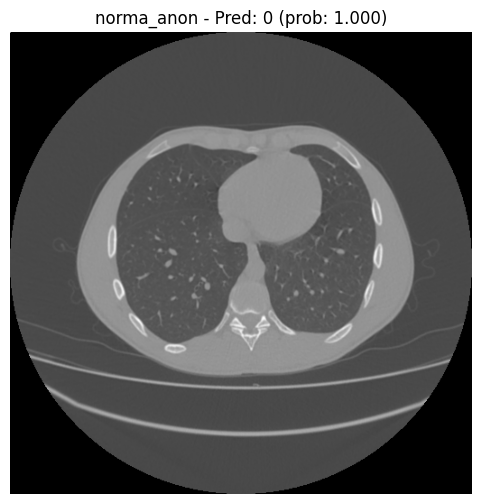


File: 1000035A_anon from pneumonia_anon
Original shape: (512, 512)
Normalized shape: (512, 512)


Predicting: 100%|██████████| 1/1 [00:00<00:00, 12.05it/s]


Prediction: 1
Probabilities: [4.0594259e-06 9.9999595e-01]
Max probability: 1.0000


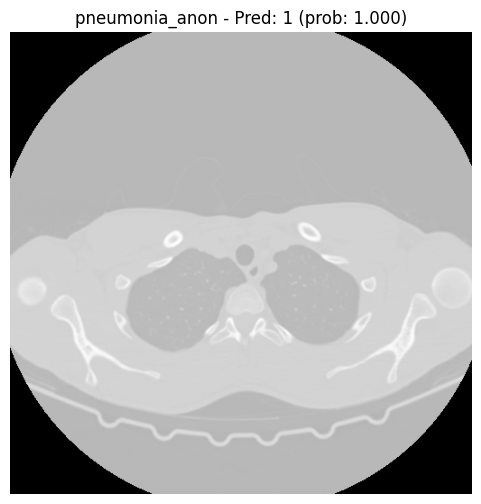


File: 100003FB_anon from pneumonia_anon
Original shape: (512, 512)
Normalized shape: (512, 512)


Predicting: 100%|██████████| 1/1 [00:00<00:00, 11.77it/s]


Prediction: 1
Probabilities: [1.2722427e-06 9.9999869e-01]
Max probability: 1.0000


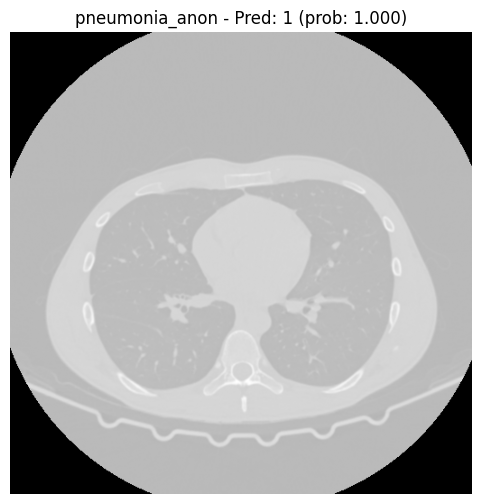


File: 100003BD_anon from pneumonia_anon
Original shape: (512, 512)
Normalized shape: (512, 512)


Predicting: 100%|██████████| 1/1 [00:00<00:00, 12.12it/s]


Prediction: 1
Probabilities: [9.0483172e-07 9.9999905e-01]
Max probability: 1.0000

File: 10000477_anon from pneumonia_anon
Original shape: (512, 512)
Normalized shape: (512, 512)


Predicting: 100%|██████████| 1/1 [00:00<00:00, 11.76it/s]


Prediction: 1
Probabilities: [7.8788173e-07 9.9999917e-01]
Max probability: 1.0000

File: 10000F31_anon from norma_anon
Original shape: (512, 512)
Normalized shape: (512, 512)


...

Prediction: 1
Probabilities: [1.1584102e-06 9.9999881e-01]
Max probability: 1.0000

File: 1000045F_anon from pneumonia_anon
Original shape: (512, 512)
Normalized shape: (512, 512)


Predicting: 100%|██████████| 1/1 [00:00<00:00, 12.08it/s]


Prediction: 1
Probabilities: [1.3200472e-06 9.9999869e-01]
Max probability: 1.0000

File: 10000EAE_anon from norma_anon
Original shape: (512, 512)
Normalized shape: (512, 512)


Predicting: 100%|██████████| 1/1 [00:00<00:00, 11.46it/s]

Prediction: 0
Probabilities: [0.91590077 0.08409921]
Max probability: 0.9159


In [2]:
base_path = Path(base_dir)

# Тестируем 10 случайных изображений
for i in range(10):
    dir_name = random.choice(dirs)
    files = list((base_path / dir_name).rglob("*"))
    file = random.choice([f for f in files if f.is_file()])

    try:
        # Читаем DICOM как одноканальное изображение
        img = read_dicom(file)

        # Нормализуем к диапазону [0, 255]
        img_min, img_max = np.min(img), np.max(img)
        if img_max > img_min:
            img_normalized = (img - img_min) / (img_max - img_min)
            img_normalized = (img_normalized * 255).astype(np.uint8)
        else:
            img_normalized = np.zeros_like(img, dtype=np.uint8)

        print(f"\nFile: {file.name} from {dir_name}")
        print(f"Original shape: {img.shape}")
        print(f"Normalized shape: {img_normalized.shape}")

        # Используем стандартный метод predict - RGB конвертация происходит автоматически
        probs = model.predict_proba([img_normalized])
        pred = model.predict([img_normalized])

        print(f"Prediction: {pred[0]}")
        print(f"Probabilities: {probs[0]}")
        print(f"Max probability: {np.max(probs[0]):.4f}")

        # Показываем изображение (опционально)
        if i < 3:  # Показываем только первые 3 изображения
            plt.figure(figsize=(6, 6))
            plt.imshow(img_normalized, cmap="gray")
            plt.title(f"{dir_name} - Pred: {pred[0]} (prob: {np.max(probs[0]):.3f})")
            plt.axis('off')
            plt.show()

    except Exception as e:
        raise e